In [1]:
import json

with open("/Users/tds122/Documents/nehack25/output.json", "r") as f:
    data = json.load(f)

print(list(data.keys()))


['players', 'teams', 'gaia', 'map', 'file', 'restored', 'restored_at', 'speed', 'speed_id', 'cheats', 'lock_teams', 'population', 'chat', 'guid', 'lobby', 'rated', 'dataset', 'type', 'type_id', 'map_reveal', 'map_reveal_id', 'difficulty', 'difficulty_id', 'starting_age', 'starting_age_id', 'team_together', 'lock_speed', 'all_technologies', 'multiqueue', 'duration', 'diplomacy_type', 'completed', 'dataset_id', 'version', 'game_version', 'save_version', 'log_version', 'build_version', 'timestamp', 'spec_delay', 'allow_specs', 'hidden_civs', 'private', 'hash', 'actions', 'inputs', 'uptimes']


In [2]:
import pandas as pd

# Convert the gaia values into pandas DataFrame
gaia_list = data["gaia"]

# Flatten 'position' dict into separate columns for each row
for row in gaia_list:
    if "position" in row:
        row["x"] = row["position"].get("x")
        row["y"] = row["position"].get("y")
        del row["position"]

gaia_df = pd.DataFrame(gaia_list)
print(gaia_df.head())


           name  class_id  object_id  instance_id  index         x          y
0  Grass, Green        10       1358            0      0  42.06778  65.821815
1           NaN        20       1902         2422      0  81.00000  64.000000
2           NaN        20       1902         2423      0  57.00000  68.000000
3           NaN        20       1902         2424      0  64.00000  69.000000
4           NaN        20       1902         2425      0  71.00000  73.000000


In [3]:
gaia_df["name"].value_counts()

name
Tree (Jungle)                  1055
Grass, Green                    809
Tree (Rainforest)               367
Plant (Jungle)                  125
Plant (Underbrush Tropical)      64
Gold Mine                        36
Stone Mine                       24
Plant (Flowers)                  20
Plant (Weeds)                    18
Goose                            14
Plant (Dead)                     12
Forage Bush                      12
Jaguar                            9
Box Turtles                       7
Macaw                             7
Plant (Shrub, Green)              6
Deer                              6
Rock 1                            5
Relic                             5
Flower Bed                        5
Stork                             4
Javelina                          4
Tree (Reeds)                      3
Name: count, dtype: int64

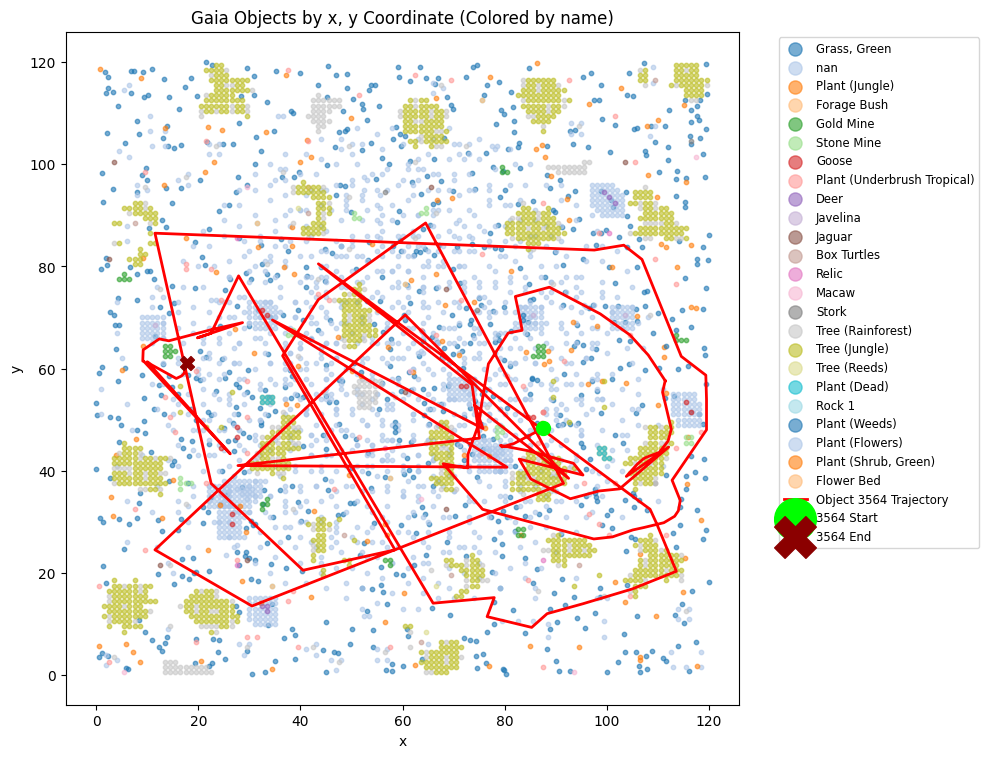

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

# Create unique colors for each 'name'
names = gaia_df["name"].astype(str)
unique_names = names.unique()
colors = (
    plt.cm.tab20.colors
)  # Up to 20 colors, can be swapped for larger palettes if needed
color_map = {name: colors[i % len(colors)] for i, name in enumerate(unique_names)}

for name in unique_names:
    subset = gaia_df[names == name]
    plt.scatter(
        subset["x"], subset["y"], alpha=0.6, s=10, color=color_map[name], label=name
    )

# Extract trajectory for object 3564 from actions
trajectory_3564 = []
for action in data["actions"]:
    if action.get("type") == "MOVE" and "position" in action:
        object_ids = action.get("payload", {}).get("object_ids", [])
        if 3564 in object_ids:
            trajectory_3564.append((action["position"]["x"], action["position"]["y"]))

# Plot trajectory as a bright red line
if trajectory_3564:
    traj_x = [p[0] for p in trajectory_3564]
    traj_y = [p[1] for p in trajectory_3564]
    plt.plot(
        traj_x,
        traj_y,
        color="red",
        linewidth=2,
        label="Object 3564 Trajectory",
        zorder=10,
    )
    # Add start and end markers
    plt.scatter(
        [traj_x[0]],
        [traj_y[0]],
        color="lime",
        s=100,
        marker="o",
        zorder=11,
        label="3564 Start",
    )
    plt.scatter(
        [traj_x[-1]],
        [traj_y[-1]],
        color="darkred",
        s=100,
        marker="X",
        zorder=11,
        label="3564 End",
    )

plt.xlabel("x")
plt.ylabel("y")
plt.title("Gaia Objects by x, y Coordinate (Colored by name)")
plt.gca().set_aspect("equal", adjustable="box")
plt.legend(markerscale=3, fontsize="small", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [5]:
# Install plotly if needed: !pip install plotly
import plotly.graph_objects as go
from collections import defaultdict

# Extract all trajectories from MOVE actions, grouped by object_id
trajectories = defaultdict(list)
for action in data["actions"]:
    if action.get("type") == "MOVE" and "position" in action:
        object_ids = action.get("payload", {}).get("object_ids", [])
        pos = (action["position"]["x"], action["position"]["y"])
        for obj_id in object_ids:
            trajectories[obj_id].append(pos)

# Build a lookup for object names from player objects
object_names = {}
for player in data.get("players", []):
    for obj in player.get("objects", []):
        instance_id = obj.get("instance_id")
        name = obj.get("name", f"Unknown")
        object_names[instance_id] = f"{name} ({instance_id}) - P{player['number']}"

print(f"Found {len(trajectories)} objects with movement trajectories")
print(f"Total move commands: {sum(len(t) for t in trajectories.values())}")


Found 115 objects with movement trajectories
Total move commands: 1529


In [6]:
# Create interactive plot with toggleable trajectories
fig = go.Figure()

# Add gaia objects as scatter (background layer)
for name in gaia_df["name"].astype(str).unique():
    subset = gaia_df[gaia_df["name"].astype(str) == name]
    fig.add_trace(
        go.Scatter(
            x=subset["x"],
            y=subset["y"],
            mode="markers",
            marker=dict(size=4, opacity=0.5),
            name=f"Gaia: {name}",
            legendgroup="gaia",
            legendgrouptitle_text="Gaia Objects",
            visible="legendonly",  # Hidden by default to reduce clutter
        )
    )

# Generate distinct colors for trajectories
import colorsys

n_trajectories = len(trajectories)
traj_colors = [
    f"hsl({int(i * 360 / n_trajectories)}, 70%, 50%)" for i in range(n_trajectories)
]

# Add each trajectory as a line
for i, (obj_id, positions) in enumerate(
    sorted(trajectories.items(), key=lambda x: -len(x[1]))
):
    if len(positions) < 2:
        continue  # Skip objects with only 1 move command

    x_coords = [p[0] for p in positions]
    y_coords = [p[1] for p in positions]

    # Get name from lookup or use generic
    label = object_names.get(obj_id, f"Object {obj_id}")

    fig.add_trace(
        go.Scatter(
            x=x_coords,
            y=y_coords,
            mode="lines+markers",
            line=dict(width=2, color=traj_colors[i % len(traj_colors)]),
            marker=dict(size=3),
            name=f"{label} ({len(positions)} moves)",
            legendgroup="trajectories",
            legendgrouptitle_text="Trajectories (click to toggle)",
            hovertemplate=f"{label}<br>x: %{{x:.1f}}<br>y: %{{y:.1f}}<extra></extra>",
        )
    )

# Layout
fig.update_layout(
    title="Object Trajectories (Click legend items to toggle visibility)",
    xaxis_title="x",
    yaxis_title="y",
    width=1000,
    height=900,
    yaxis=dict(scaleanchor="x", scaleratio=1),
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=1.02,
        bgcolor="rgba(255,255,255,0.8)",
        font=dict(size=10),
        itemsizing="constant",
    ),
    hovermode="closest",
)

fig.show()


In [10]:
# Extract all MOVE actions as a flat list (preserving order)
move_actions = []
for action in data["actions"]:
    if action.get("type") == "MOVE" and "position" in action:
        move_actions.append(action)

print(f"Total MOVE actions: {len(move_actions)}")


Total MOVE actions: 690


In [12]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
from collections import defaultdict

# Build object name lookup
object_names = {}
for player in data.get("players", []):
    for obj in player.get("objects", []):
        instance_id = obj.get("instance_id")
        name = obj.get("name", "Unknown")
        object_names[instance_id] = f"{name} (P{player['number']})"

# Output widget to hold the plot
output = widgets.Output()


def plot_first_n_moves(n):
    """Plot the first n MOVE actions"""
    with output:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(10, 10))

        # Plot gaia objects as background
        ax.scatter(gaia_df["x"], gaia_df["y"], alpha=0.3, s=5, c="gray", label="Gaia")

        # Get first n move actions
        selected_moves = move_actions[:n]

        # Group by object_id to draw connected trajectories
        trajectories = defaultdict(list)
        for action in selected_moves:
            object_ids = action.get("payload", {}).get("object_ids", [])
            pos = (action["position"]["x"], action["position"]["y"])
            for obj_id in object_ids:
                trajectories[obj_id].append(pos)

        # Generate colors for each object
        n_objs = max(len(trajectories), 1)
        colors = plt.cm.rainbow([i / n_objs for i in range(n_objs)])

        # Plot each trajectory
        for i, (obj_id, positions) in enumerate(trajectories.items()):
            x_coords = [p[0] for p in positions]
            y_coords = [p[1] for p in positions]
            label = object_names.get(obj_id, f"Object {obj_id}")

            # Plot line connecting points
            ax.plot(
                x_coords, y_coords, color=colors[i], linewidth=2, alpha=0.8, label=label
            )
            # Plot points
            ax.scatter(x_coords, y_coords, color=colors[i], s=30, zorder=5)
            # Mark start with circle
            ax.scatter(
                [x_coords[0]],
                [y_coords[0]],
                color=colors[i],
                s=100,
                marker="o",
                edgecolors="black",
                linewidths=1,
                zorder=6,
            )
            # Mark end with X
            if len(x_coords) > 1:
                ax.scatter(
                    [x_coords[-1]],
                    [y_coords[-1]],
                    color=colors[i],
                    s=100,
                    marker="X",
                    edgecolors="black",
                    linewidths=1,
                    zorder=6,
                )

        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_title(f"First {n} MOVE actions ({len(trajectories)} objects)")
        ax.set_aspect("equal", adjustable="box")
        ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
        plt.tight_layout()
        plt.show()


# Create slider
slider = widgets.IntSlider(
    value=10,
    min=1,
    max=len(move_actions),
    step=1,
    description="# Moves:",
    continuous_update=False,
    style={"description_width": "initial"},
    layout=widgets.Layout(width="80%"),
)

# Link slider to function
slider.observe(lambda change: plot_first_n_moves(change["new"]), names="value")

# Display slider and output
display(slider, output)

# Initial plot
plot_first_n_moves(10)


IntSlider(value=10, continuous_update=False, description='# Moves:', layout=Layout(width='80%'), max=690, min=…

Output()

In [ ]:
gaia_df[gaia_df["object_id"] == "3564"].shape

(0, 7)